In [3]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.13.0+cu130'

Data Preparing & Loading

In [4]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [5]:
len(y)

50

Spliting Data

In [6]:
train_split = int(0.8 * len(X))
train_split

X_train, y_train = X[:train_split], y[:train_split]

X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [7]:
def plot_predictions(train_data=X_train,
                     train_label=y_train,
                     test_data=X_test,
                     test_label=y_test,
                     predictions=None):
  plt.figure(figsize=(10, 7))
  
  # plot training data 
  plt.scatter(train_data, train_label, c="b", s=4, label="Training Data")

  # plot test data 
  plt.scatter(test_data, test_label, c="g", s=4, label="Testing Data")

  # are there predictions

  if predictions is not None:
    # plot the predections if they exist
    plt.scatter(test_data, predictions, c='r', s=4, label="Predictions")

  plt.legend(prop={"size": 14})




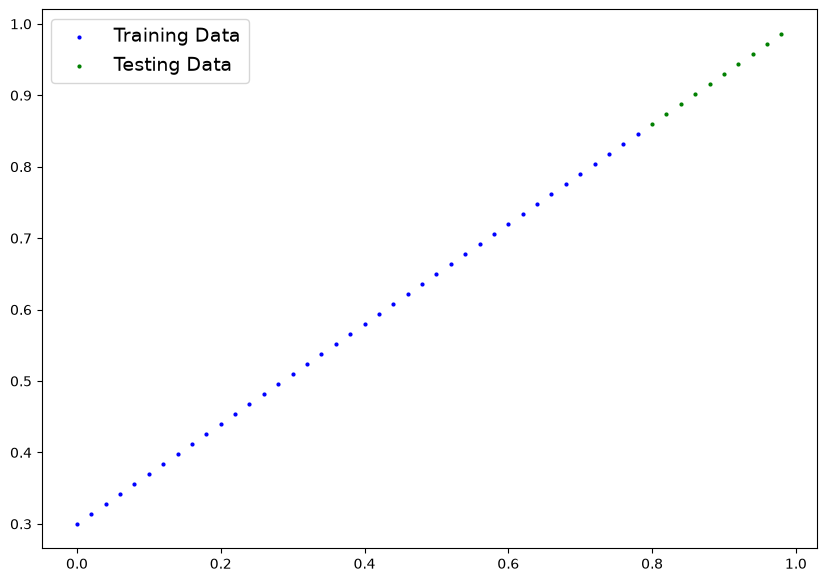

In [8]:
plot_predictions()

Build Model

In [9]:
from torch import nn

# linear regression model class

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, 
                                            requires_grad=True,
                                            dtype=torch.float))
    
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))
    
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

In [10]:
# create random seed
torch.manual_seed(42)

# create instace of model 
model_0 = LinearRegressionModel()

# checkout parameter
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
# list named parameter
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [12]:
weight, bias

(0.7, 0.3)

making prediction using ```torch.inference_mode()```


In [13]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [14]:
# make prediction with model
with torch.inference_mode():
  y_preds = model_0(X_test)


# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [15]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

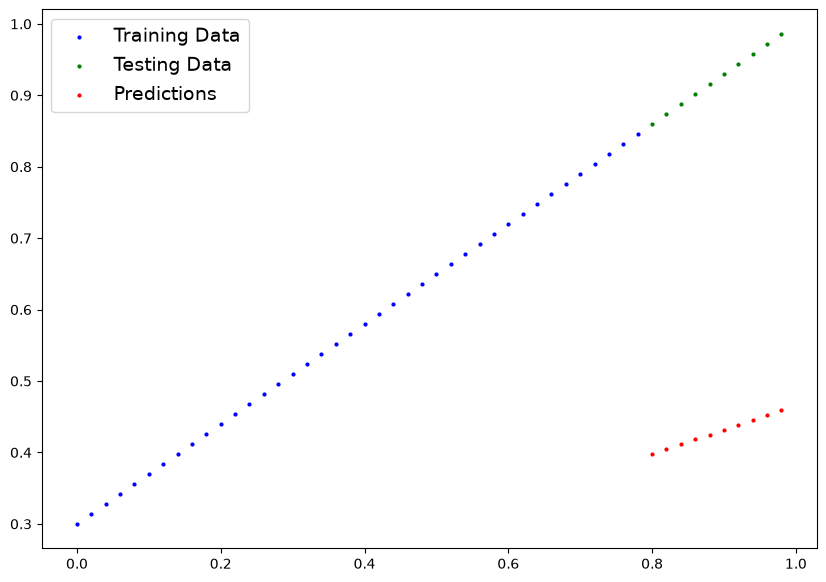

In [16]:
plot_predictions(predictions=y_preds)

Training Model


In [17]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [18]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [19]:
# setup loss function
loss_fn = nn.L1Loss()

# setup optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) # lr = learning rate

In [20]:
loss_fn

L1Loss()

Build Training Loop

In [21]:
torch.manual_seed(42)

# epoch is one loops because is one
epochs = 100

epoch_count = []
loss_values = []
test_loss_values = []

# Loop through the data
for epoch in range(epochs):
  # set the model training mode
  model_0.train(); # train mode

  #1. forwqrd pass
  y_preds = model_0(X_train)

  #2. Calculate the loss
  loss = loss_fn(y_preds, y_train)
  # print(f'Loss: {loss}')

  #3 optimize 
  optimizer.zero_grad()

  #4 backpropagation
  loss.backward()

  #5 step the optimizer
  optimizer.step()

  model_0.eval() # turn off gradient tracking

  with torch.inference_mode():
    # 1. do the forward
    test_pred = model_0(X_test)

    # 2. valculate loss
    test_loss = loss_fn(test_pred, y_test)

  # print what happent
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f'Epoch {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss}')
    print(model_0.state_dict())

Epoch 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135


In [22]:
import numpy as np

C:\Users\Kadek Wira\AppData\Local\Temp\ipykernel_7360\3747580994.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train Loss")


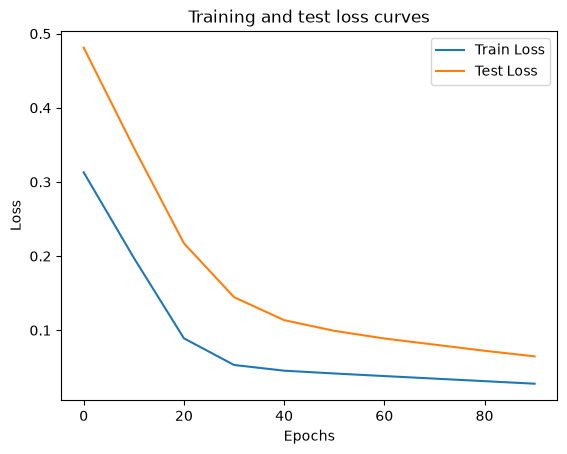

In [23]:
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

In [24]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)

In [25]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [26]:
weight, bias

(0.7, 0.3)

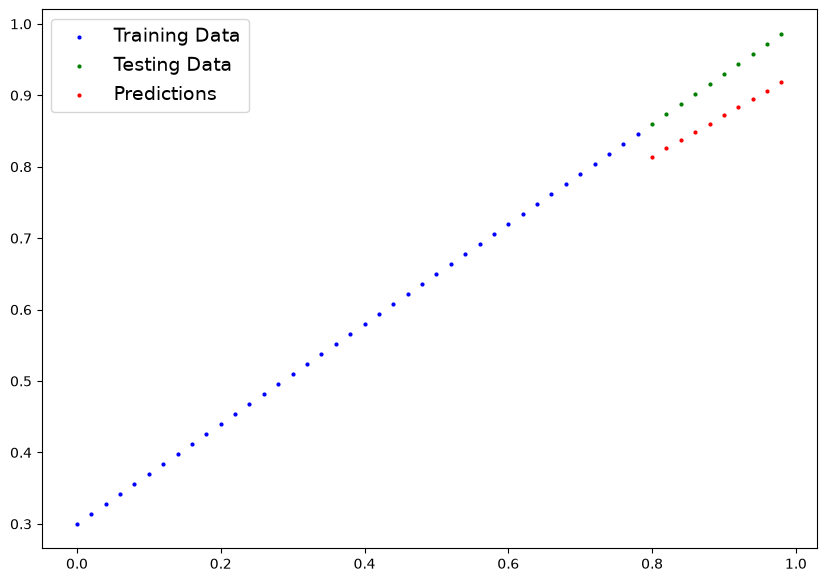

In [27]:
plot_predictions(predictions=(y_preds_new))

Saving Model 

In [28]:
# saving our model
from pathlib import Path

# 1 Create models directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# MODEL_SAVE_PATH

# 3 . Save Model 
print(f'Saving Model To : {MODEL_SAVE_PATH}')
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving Model To : models\01_workflow_model_0.pth


Load Save Model

In [29]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [30]:
loaded_model_0 = LinearRegressionModel()

# Load the save model

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


<All keys matched successfully>

In [31]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [32]:
# Make Predictions 
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

In [33]:
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

In [34]:
# Compare loaded model preds
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [35]:
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.__version__

'2.13.0+cu130'

In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Using Device : {device}')

Using Device : cuda


Data (Ini Cerita Nya Ngulang Agar benar benar paham alur)

In [37]:
# create some data 
weight = 0.7
bias = 0.3

# create range values
start = 0
end = 1
step = 0.02

# create x and y 
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [38]:
# split data

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]

X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

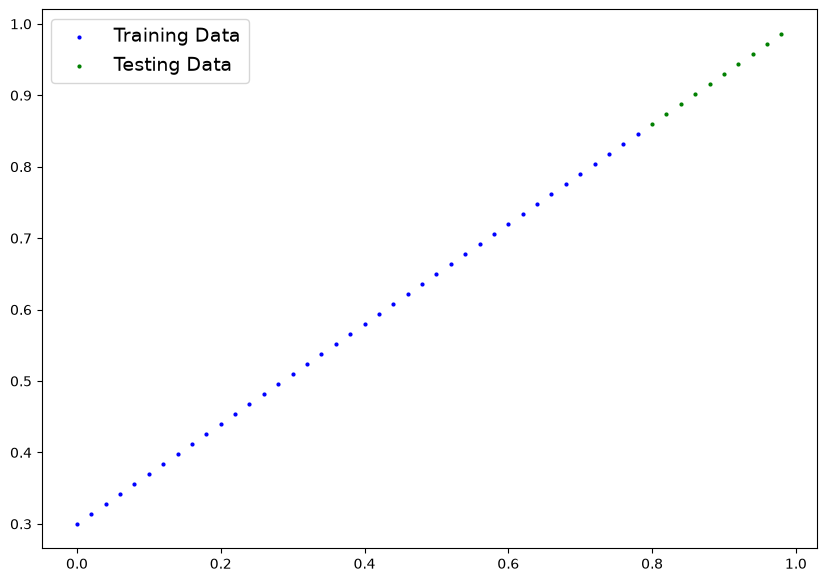

In [39]:
# plot 

plot_predictions(X_train, y_train, X_test, y_test)

Building Linear Model

In [40]:
# crete linear model 

class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer = nn.Linear(in_features=1, out_features=1)
    
  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)
  
# set seed 

torch.manual_seed(42)
model_1 = LinearRegressionModelV2()

model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [41]:
# check the model curent device

next(model_1.parameters()).device

device(type='cpu')

In [42]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

Training

In [43]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [ ]:
# Traiing Loop

torch.manual_seed(42)

epoch = 200

epoch_count = []
train_loss_values = []
test_loss_values = []

# Put data on target device 
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epoch):
  model_1.train()

  # Forward pass
  y_pred = model_1(X_train)

  # calculate the loss
  loss = loss_fn(y_pred, y_train)

  # optimizer zero grad
  optimizer.zero_grad()

  # perform backpropagation
  loss.backward()

  # optimizer step
  optimizer.step()

  # Testing
  model_0.eval()

  with torch.inference_mode():
    test_pred = model_1(X_test)

    test_loss = loss_fn(test_pred, y_test)

  # print

  if(epoch % 10 == 0):
    print(f"epoch : {epoch} | loss : {loss} | Test Lost : {test_loss}")


epoch : 0 | loss : 0.5551779270172119 | Test Lost : 0.5739762187004089
epoch : 10 | loss : 0.4399681091308594 | Test Lost : 0.4392664134502411
epoch : 20 | loss : 0.3247582018375397 | Test Lost : 0.30455657839775085
epoch : 30 | loss : 0.20954833924770355 | Test Lost : 0.16984669864177704
epoch : 40 | loss : 0.09433844685554504 | Test Lost : 0.03513690456748009
epoch : 50 | loss : 0.023886388167738914 | Test Lost : 0.04784907028079033
epoch : 60 | loss : 0.019956795498728752 | Test Lost : 0.045803118497133255
epoch : 70 | loss : 0.016517987474799156 | Test Lost : 0.037530567497015
epoch : 80 | loss : 0.013089174404740334 | Test Lost : 0.02994490973651409
epoch : 90 | loss : 0.009653178043663502 | Test Lost : 0.02167237363755703
epoch : 100 | loss : 0.006215683650225401 | Test Lost : 0.014086711220443249
epoch : 110 | loss : 0.00278724217787385 | Test Lost : 0.005814164876937866
epoch : 120 | loss : 0.0012645035749301314 | Test Lost : 0.013801801018416882
epoch : 130 | loss : 0.00126450

In [45]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [46]:
weight, bias

(0.7, 0.3)

Making Evaluating Predictions

In [47]:
model_1.eval()

with torch.inference_mode():
  y_preds = model_1(X_test)

y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

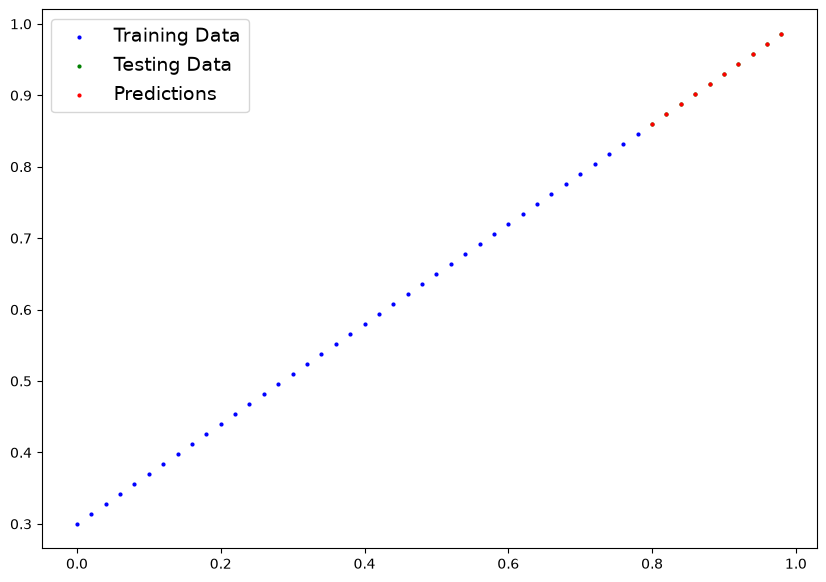

In [48]:
plot_predictions(predictions=y_preds.cpu())

Saving and Load

In [49]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f'Saving Model to : {MODEL_SAVE_PATH}')
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

Saving Model to : models\01_pytorch_workflow_1.pth


In [50]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

Load Model

In [51]:
loaded_model_1 = LinearRegressionModelV2()

loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [52]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [53]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [54]:
# evaluate loaded model

loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_1_preds = loaded_model_1(X_test)

y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')